# M02 · 二次量子化、Wick 定理与散射理论

**核心问题**：如何自然描述粒子数可变的量子系统？

```
单粒子 H 空间 → Fock 空间 → 产生/湮灭算符 → 场算符 → Wick 定理 → Green 函数 → 散射截面
```

**逻辑**：二次量子化 ≠ 量子化两次。它是把"粒子数"变成动力学变量的表象变换。

运行：`conda activate m01`

---
## 0. 符号约定速查表

### 括号

| 符号 | 名称 | 含义 | 例 |
|------|------|------|-----|
| $[A, B]$ | **对易子** (commutator) | $AB - BA$ | $[x, p] = i\hbar$ |
| $\{A, B\}$ | **反对易子** (anticommutator) | $AB + BA$ | $\{a_i, a_j^\dagger\} = \delta_{ij}$ |
| $\{f, g\}_{PB}$ | **Poisson 括号** (经典) | $\sum_i (\partial_q f\,\partial_p g - \partial_p f\,\partial_q g)$ | $\{q, p\}_{PB} = 1$ |
| $\langle a \vert b \rangle$ | **内积** | Hilbert 空间标量积 | $\langle \phi \vert \psi \rangle$ |
| $\langle A \rangle$ | **期望值** | $\langle \psi \vert A \vert \psi \rangle$ 或 $\text{Tr}(\rho A)$ | $\langle n \rangle$ |
| $\langle 0 \vert T[AB] \vert 0 \rangle$ | **传播子** | 编时真空期望 = $G_F(x-y)$ |

### 算符排序

| 符号 | 名称 | 规则 |
|------|------|------|
| $T[A(t_1)B(t_2)]$ | **编时积** (time ordering) | 时间早的放右边；费米子交换加负号 |
| $:AB:$ | **正规序** (normal ordering) | 所有 $a^\dagger$ 在左，$a$ 在右。$\langle 0 \vert :O: \vert 0 \rangle = 0$ |
| $P[e^{\int A}]$ | **路径序** (path ordering) | 非 Abel 规范理论：参数大的在左 |

### 核心公式

**Dyson 级数**（相互作用绘景时间演化）：

$$U(t, t_0) = T\exp\!\left(-\frac{i}{\hbar}\int_{t_0}^t H_I(t')\,dt'\right) = \sum_{n=0}^{\infty}\frac{(-i)^n}{n!\,\hbar^n}\int dt_1\cdots dt_n\; T[H_I(t_1)\cdots H_I(t_n)]$$

**路径积分**（配分函数）：

$$Z[J] = \int \mathcal{D}\phi\; e^{\frac{i}{\hbar}S[\phi] + \frac{i}{\hbar}\int J\phi} \quad\text{(Minkowski)}, \qquad Z[J] = \int \mathcal{D}\phi\; e^{-S_E[\phi] + \int J\phi} \quad\text{(Euclidean)}$$

**Wick 定理**（编时积 → 正规序 + 收缩）：

$$T[A_1 A_2 \cdots A_n] = :A_1 A_2 \cdots A_n: + \sum_{\text{all contractions}}$$

**收缩** = 编时真空期望（c 数）= Feynman 传播子：

$$\text{contraction of } A_1 A_2 \equiv \langle 0|T[A_1 A_2]|0\rangle$$

### 量子化对应

| 经典 | 量子 |
|------|------|
| $\{f,g\}_{PB}$ | $\frac{1}{i\hbar}[\hat{f}, \hat{g}]$ |
| 相空间 $(q,p)$ | Hilbert 空间 $|\psi\rangle$ |
| 正则系综 $e^{-\beta H}$ | 密度矩阵 $\hat{\rho} = e^{-\beta\hat{H}}/Z$ |
| 路径 $q(t)$ | 路径积分 $\int\mathcal{D}q$ |
| 可观测量 $A(q,p)$ | 算符 $\hat{A}$ |

### 括号嵌套读法

$$\langle 0 \vert T[:\hat{\psi}^\dagger(x)\hat{\psi}(x)::\hat{\psi}^\dagger(y)\hat{\psi}(y):] \vert 0 \rangle$$

从内到外：
1. $:\cdots:$ — 正规序（去掉真空涨落）
2. $T[\cdots]$ — 编时积（按时间排列）
3. $\langle 0\vert\cdots\vert 0\rangle$ — 真空期望（得到 c 数 = Green 函数）

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy import (symbols, Function, exp, sqrt, pi, simplify, Rational,
                   Eq, Integral, oo, Matrix, KroneckerDelta, Integer)
from IPython.display import display, Math, Markdown

sp.init_printing(use_latex='mathjax')
plt.rcParams['font.family'] = ['Arial Unicode MS', 'PingFang SC', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (12, 5)

---
## 1. 为什么需要 Fock 空间

**一次量子化**：固定 $N$ 个粒子，波函数 $\psi(\mathbf{r}_1, \ldots, \mathbf{r}_N)$。

问题：
- 粒子数不守恒（粒子物理：$e^+e^- \to \mu^+\mu^-$）
- 全同粒子对称化随 $N$ 阶乘增长（$N!$ 项）
- 无法描述凝聚（BEC：宏观占据单态）

**解决**：Fock 空间 = 所有粒子数子空间的直和：

$$\mathcal{F} = \mathcal{H}_0 \oplus \mathcal{H}_1 \oplus \mathcal{H}_2 \oplus \cdots = \bigoplus_{N=0}^{\infty} \mathcal{H}_N$$

其中 $\mathcal{H}_N$ 是 $N$ 粒子（对称/反对称）子空间。

findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 600.


findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 600.


findfont: Failed to find font weight bold, now using 400.


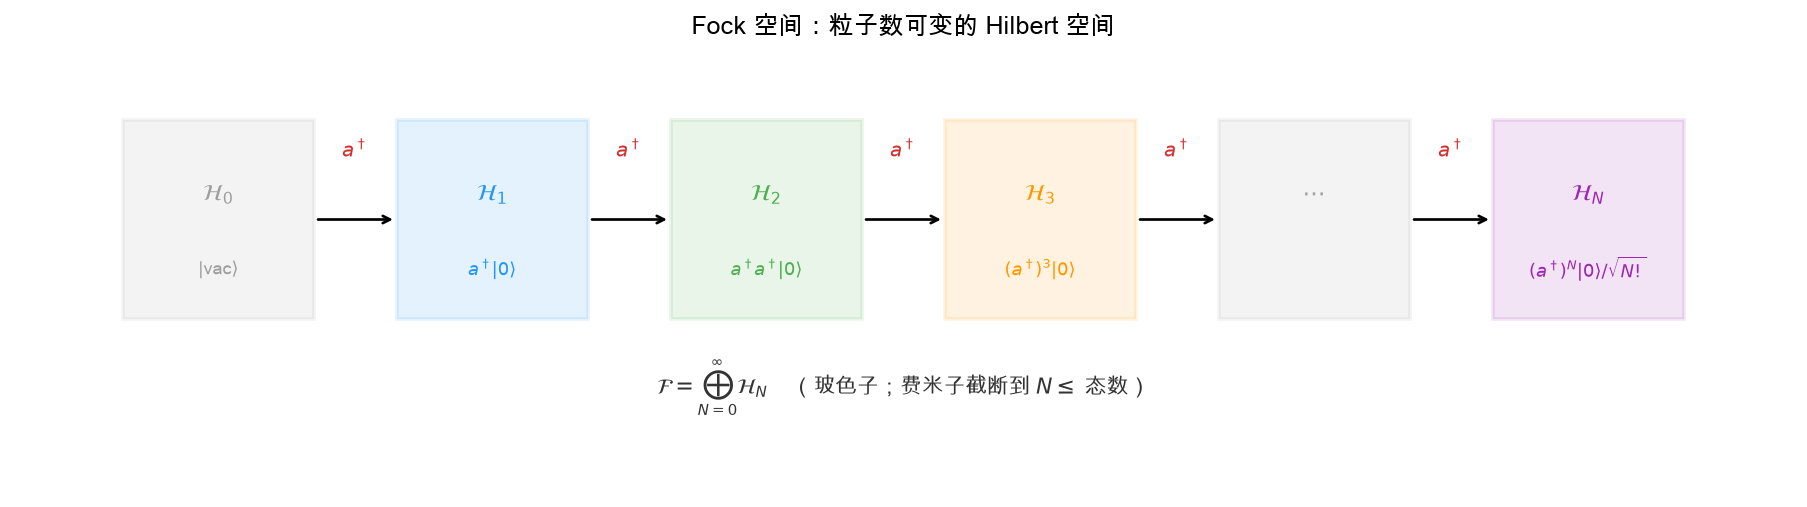

In [2]:
# Fock 空间结构可视化
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_title('Fock 空间：粒子数可变的 Hilbert 空间', fontsize=14, fontweight='bold')
spaces = [
    (r'$\mathcal{H}_0$', '|vac⟩', '#9E9E9E'),
    (r'$\mathcal{H}_1$', r'$a^\dagger|0\rangle$', '#2196F3'),
    (r'$\mathcal{H}_2$', r'$a^\dagger a^\dagger|0\rangle$', '#4CAF50'),
    (r'$\mathcal{H}_3$', r'$(a^\dagger)^3|0\rangle$', '#FF9800'),
    (r'$\cdots$', '', '#9E9E9E'),
    (r'$\mathcal{H}_N$', r'$(a^\dagger)^N|0\rangle/\sqrt{N!}$', '#9C27B0'),
]
xpos = [0, 2, 4, 6, 8, 10]
for i, (label, state, color) in enumerate(spaces):
    x = xpos[i]
    rect = plt.Rectangle((x-0.7, -0.4), 1.4, 0.8, facecolor=color, alpha=0.12, edgecolor=color, lw=2)
    ax.add_patch(rect)
    ax.text(x, 0.1, label, ha='center', va='center', fontsize=13, color=color, fontweight='bold')
    if state:
        ax.text(x, -0.2, state, ha='center', va='center', fontsize=10, color=color)
    if i < len(spaces)-1:
        ax.annotate('', xy=(xpos[i+1]-0.7, 0), xytext=(x+0.7, 0),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
        ax.text((x+xpos[i+1])/2, 0.25, r'$a^\dagger$', ha='center', fontsize=11, color='#D32F2F')
ax.text(5, -0.7, r'$\mathcal{F} = \bigoplus_{N=0}^{\infty} \mathcal{H}_N$    （玻色子；费米子截断到 $N \leq$ 态数）',
        ha='center', fontsize=12, color='#333')
ax.set_xlim(-1.5, 11.5); ax.set_ylim(-1.1, 0.7); ax.axis('off')
plt.tight_layout(); plt.savefig('fig_fock_space.png', bbox_inches='tight', dpi=150); plt.show()

---
## 2. 产生/湮灭算符

**玻色子**（对易）：
$$[a_i, a_j^\dagger] = \delta_{ij}, \quad [a_i, a_j] = [a_i^\dagger, a_j^\dagger] = 0$$

**费米子**（反对易）：
$$\{a_i, a_j^\dagger\} = \delta_{ij}, \quad \{a_i, a_j\} = \{a_i^\dagger, a_j^\dagger\} = 0$$

**物理原因**：自旋-统计定理。半整数自旋 → 交换反对称 → 反对易 → Pauli 排除（$n_i \in \{0,1\}$）。

**数算符**：$\hat{n}_i = a_i^\dagger a_i$，本征值 = 占据数。

In [3]:
# 用矩阵表示验证玻色子/费米子代数
display(Markdown("### 费米子：2x2 矩阵表示（单模）"))
a_f = Matrix([[0, 1], [0, 0]])
ad_f = Matrix([[0, 0], [1, 0]])
n_f = ad_f * a_f

display(Markdown(r"$a = \begin{pmatrix}0&1\\0&0\end{pmatrix}$, $a^\dagger = \begin{pmatrix}0&0\\1&0\end{pmatrix}$"))
display(Markdown(r"**反对易关系** $\{a, a^\dagger\} = aa^\dagger + a^\dagger a$："))
display(a_f*ad_f + ad_f*a_f)
display(Markdown(r"**数算符** $\hat{n} = a^\dagger a$："))
display(n_f)
display(Markdown(r"本征值 0, 1 → Pauli 排除。$\checkmark$"))

display(Markdown("### 玻色子：截断到 $n_{max}=4$ 的矩阵表示"))
N_max = 5
a_b = Matrix(N_max, N_max, lambda i, j: sqrt(Integer(j))*KroneckerDelta(i, j-1) if j > 0 else 0)
ad_b = a_b.T
n_b = ad_b * a_b
display(Markdown(r"**对易关系** $[a, a^\dagger] = I$（截断近似）："))
display(a_b*ad_b - ad_b*a_b)
display(Markdown("**数算符对角元** = 占据数 0,1,2,3,4："))
display(Matrix([n_b[i,i] for i in range(N_max)]).T)

### 费米子：2x2 矩阵表示（单模）

$a = \begin{pmatrix}0&1\\0&0\end{pmatrix}$, $a^\dagger = \begin{pmatrix}0&0\\1&0\end{pmatrix}$

**反对易关系** $\{a, a^\dagger\} = aa^\dagger + a^\dagger a$：

⎡1  0⎤
⎢    ⎥
⎣0  1⎦

**数算符** $\hat{n} = a^\dagger a$：

...

### 玻色子：截断到 $n_{max}=4$ 的矩阵表示

**对易关系** $[a, a^\dagger] = I$（截断近似）：

⎡1  0  0  0  0 ⎤
⎢              ⎥
⎢0  1  0  0  0 ⎥
⎢              ⎥
⎢0  0  1  0  0 ⎥
⎢              ⎥
⎢0  0  0  1  0 ⎥
⎢              ⎥
⎣0  0  0  0  -4⎦

**数算符对角元** = 占据数 0,1,2,3,4：

[0  1  2  3  4]

---
## 3. 场算符与二次量子化哈密顿量

选单粒子基 $\{|\alpha\rangle\}$，定义**场算符**：

$$\hat{\psi}(\mathbf{r}) = \sum_\alpha \phi_\alpha(\mathbf{r})\, a_\alpha$$

其中 $\phi_\alpha(\mathbf{r}) = \langle\mathbf{r}|\alpha\rangle$ 是单粒子波函数。

**二次量子化哈密顿量**（一般形式）：

$$\hat{H} = \int d^3r\; \hat{\psi}^\dagger(\mathbf{r})\left(-\frac{\hbar^2}{2m}\nabla^2 + V(\mathbf{r})\right)\hat{\psi}(\mathbf{r}) + \frac{1}{2}\int d^3r\,d^3r'\; \hat{\psi}^\dagger(\mathbf{r})\hat{\psi}^\dagger(\mathbf{r}') V_{int}(\mathbf{r}-\mathbf{r}') \hat{\psi}(\mathbf{r}')\hat{\psi}(\mathbf{r})$$

**关键洞察**：这不是"第二次量子化"。$\hat{\psi}(\mathbf{r})$ 不是波函数，而是**算符值分布**（operator-valued distribution）。一次量子化把 $x,p$ 变成算符；二次量子化把**波函数本身**变成算符。

In [4]:
# 谐振子的二次量子化
display(Markdown(r"### 例：谐振子 $H = \hbar\omega(a^\dagger a + 1/2)$"))
hbar, omega = symbols('hbar omega', positive=True)
n_op = sp.Symbol('n', integer=True, nonneg=True)
E_n = hbar * omega * (n_op + Rational(1, 2))
display(Markdown("**能谱：**"))
display(Eq(sp.Symbol('E_n'), E_n))
display(Markdown(r"**Fock 态**：$|n\rangle = \frac{(a^\dagger)^n}{\sqrt{n!}}|0\rangle$"))
display(Markdown(r"**验证** $a^\dagger a |n\rangle = n|n\rangle$："))
display(Eq(sp.Symbol(r'a^\dagger a |n\rangle'), n_op * sp.Symbol(r'|n\rangle')))

# 坐标表象波函数
x, m_s, h = symbols('x m hbar', real=True, positive=True)
alpha_s = sqrt(m_s * omega / h)
psi_0 = (alpha_s**2/pi)**Rational(1,4) * exp(-alpha_s**2 * x**2 / 2)
psi_1 = sqrt(Integer(2)) * alpha_s * x * psi_0
display(Markdown(r"**基态波函数** $\psi_0(x)$："))
display(psi_0)
display(Markdown(r"**第一激发态** $\psi_1(x) = \sqrt{2}\alpha x\,\psi_0(x)$："))
display(psi_1)

### 例：谐振子 $H = \hbar\omega(a^\dagger a + 1/2)$

**能谱：**

Eₙ = h̅⋅ω⋅(n + 1/2)

**Fock 态**：$|n\rangle = \frac{(a^\dagger)^n}{\sqrt{n!}}|0\rangle$

**验证** $a^\dagger a |n\rangle = n|n\rangle$：

a__\dagger a |n\rangle = n⋅|n\rangle

**基态波函数** $\psi_0(x)$：

                   2 
             -m⋅ω⋅x  
             ────────
4 ___ 4 ___    2⋅h̅   
╲╱ m ⋅╲╱ ω ⋅ℯ        
─────────────────────
     4 ___ 4 ___     
     ╲╱ π ⋅╲╱ h̅      

**第一激发态** $\psi_1(x) = \sqrt{2}\alpha x\,\psi_0(x)$：

                      2 
                -m⋅ω⋅x  
                ────────
    3/4  3/4      2⋅h̅   
√2⋅m   ⋅ω   ⋅x⋅ℯ        
────────────────────────
       4 ___  3/4       
       ╲╱ π ⋅h̅          

---
## 4. Wick 定理

### 陈述

对自由场（Gaussian 理论），**编时积**等于**正规序**加上**所有可能的收缩**：

$$T[\hat{A}_1 \hat{A}_2 \cdots \hat{A}_n] = :\hat{A}_1 \hat{A}_2 \cdots \hat{A}_n: + \sum_{\text{all contractions}} :(\text{contracted pairs}):$$

其中**收缩** = 两个算符的真空期望值 = Feynman 传播子。

### 为什么有效？

自由场作用量是二次型 $S_0 = \frac{1}{2}\phi K \phi$，路径积分是 Gaussian。

Gaussian 矩的因子化（Isserlis 定理）：

$$\langle \phi_1\phi_2\phi_3\phi_4\rangle = \langle\phi_1\phi_2\rangle\langle\phi_3\phi_4\rangle + \langle\phi_1\phi_3\rangle\langle\phi_2\phi_4\rangle + \langle\phi_1\phi_4\rangle\langle\phi_2\phi_3\rangle$$

**奇数点函数 = 0**（Gaussian 对称性）。

In [5]:
# Wick 定理：4 点函数的完全收缩
display(Markdown("### 4 点函数的 Wick 分解"))
display(Math(r"\langle 0|T[\phi_1\phi_2\phi_3\phi_4]|0\rangle = G_{12}G_{34} + G_{13}G_{24} + G_{14}G_{23}"))
display(Markdown(r"其中 $G_{ij} = \langle 0|T[\phi_i\phi_j]|0\rangle$ 是 Feynman 传播子。"))

display(Markdown("### 收缩计数"))
display(Markdown(r"$n$ 点函数（$n$ 偶数）的完全收缩数 = $(n-1)!! = (n-1)(n-3)\cdots 3\cdot 1$"))

def double_factorial(n):
    result = 1
    for k in range(n-1, 0, -2):
        result *= k
    return result

for n in [2, 4, 6, 8]:
    nf = double_factorial(n)
    display(Math(r"\langle\phi_1\cdots\phi_{%d}\rangle: \; (%d-1)!! = %d \;\text{contractions}" % (n, n, nf)))

display(Markdown(r"**物理意义**：每个收缩 = 一条 Feynman 传播子线。$(n-1)!!$ 个收缩 = $(n-1)!!$ 个 Feynman 图（$\phi^4$ 理论）。"))

### 4 点函数的 Wick 分解

<IPython.core.display.Math object>

其中 $G_{ij} = \langle 0|T[\phi_i\phi_j]|0\rangle$ 是 Feynman 传播子。

### 收缩计数

$n$ 点函数（$n$ 偶数）的完全收缩数 = $(n-1)!! = (n-1)(n-3)\cdots 3\cdot 1$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**物理意义**：每个收缩 = 一条 Feynman 传播子线。$(n-1)!!$ 个收缩 = $(n-1)!!$ 个 Feynman 图（$\phi^4$ 理论）。

### n=4 的所有完全收缩（完美匹配）

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 收缩 ↔ Feynman 图（内线配对）

findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 600.


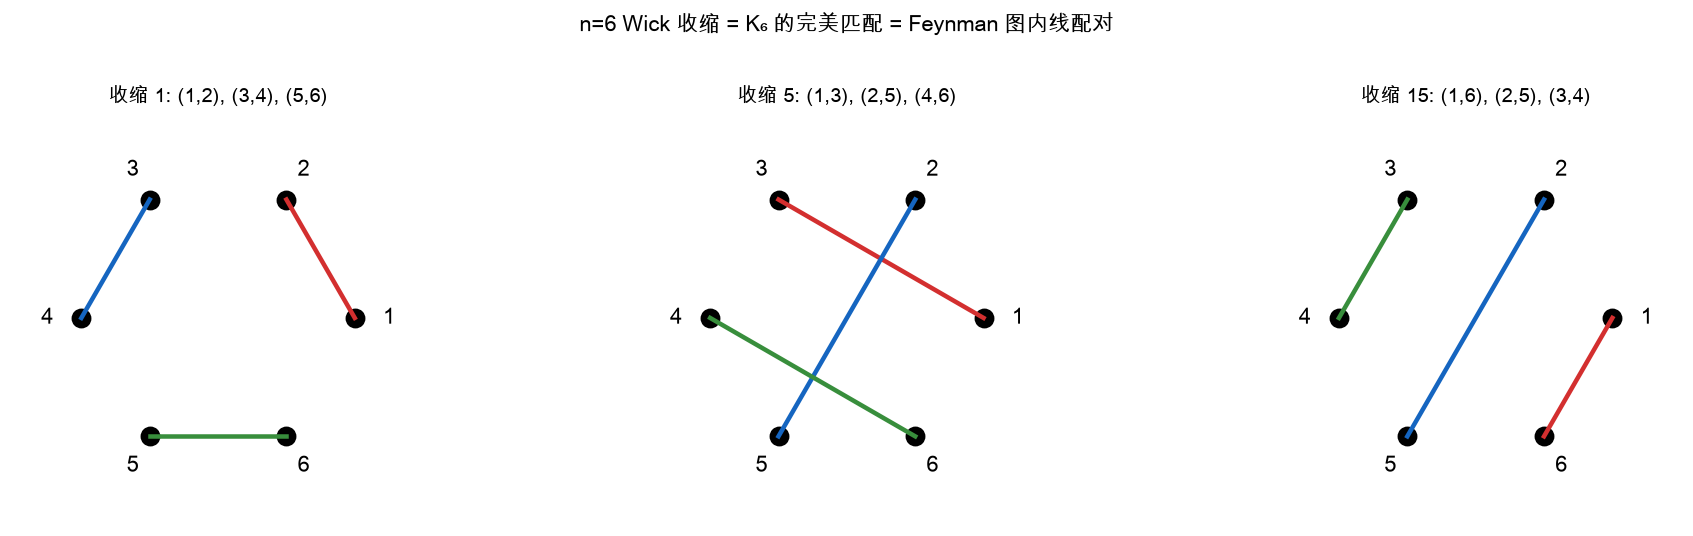

In [6]:
# Wick 收缩 = 完全图的完美匹配（组合枚举）
from itertools import combinations

def perfect_matchings(vertices):
    """枚举完全图 K_n 的所有完美匹配"""
    if len(vertices) == 0:
        yield []
        return
    v0 = vertices[0]
    rest = vertices[1:]
    for i, v in enumerate(rest):
        pair = (v0, v)
        remaining = rest[:i] + rest[i+1:]
        for matching in perfect_matchings(remaining):
            yield [pair] + matching

# n=4: 3 个收缩
display(Markdown("### n=4 的所有完全收缩（完美匹配）"))
matchings_4 = list(perfect_matchings([1,2,3,4]))
for i, m in enumerate(matchings_4):
    pairs_str = ' '.join([rf'G_{{{a}{b}}}' for a, b in m])
    display(Math(rf'\langle\phi_1\phi_2\phi_3\phi_4\rangle_{{\text{{term {i+1}}}}} = {pairs_str}'))
display(Math(r'\text{total} = 3 = (4-1)!!'))

# n=6: 15 个收缩
display(Markdown("### n=6 的所有完全收缩"))
matchings_6 = list(perfect_matchings([1,2,3,4,5,6]))
display(Math(r'\text{total} = %d = (6-1)!! = 5\times 3\times 1' % len(matchings_6)))
# 展示前 5 个
for i, m in enumerate(matchings_6[:5]):
    pairs_str = r'\cdot '.join([rf'G_{{{a}{b}}}' for a, b in m])
    display(Math(rf'\text{{({i+1})}}\quad {pairs_str}'))
display(Math(r'\cdots \quad \text{(共 15 项)}'))

# 可视化: n=6 的一个收缩对应一个 Feynman 图
display(Markdown("### 收缩 ↔ Feynman 图（内线配对）"))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
examples = [matchings_6[0], matchings_6[4], matchings_6[14]]
titles = ['收缩 1', '收缩 5', '收缩 15']
for ax, m, title in zip(axes, examples, titles):
    # 6 个顶点排成圆
    angles = np.linspace(0, 2*np.pi, 7)[:-1]
    pos = {i+1: (np.cos(a), np.sin(a)) for i, a in enumerate(angles)}
    for v in range(1, 7):
        ax.plot(*pos[v], 'ko', markersize=10)
        ax.text(pos[v][0]*1.25, pos[v][1]*1.25, str(v), ha='center', va='center', fontsize=12, fontweight='bold')
    colors = ['#D32F2F', '#1565C0', '#388E3C']
    for (a, b), c in zip(m, colors):
        ax.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]], '-', color=c, lw=2.5)
    pairs_str = ', '.join([f'({a},{b})' for a, b in m])
    ax.set_title(f'{title}: {pairs_str}', fontsize=11)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_aspect('equal'); ax.axis('off')
plt.suptitle('n=6 Wick 收缩 = K₆ 的完美匹配 = Feynman 图内线配对', fontsize=12, y=1.02)
plt.tight_layout(); plt.savefig('fig_wick_matchings.png', bbox_inches='tight', dpi=150); plt.show()

In [7]:
# 验证：Gaussian 积分的 4 点函数
display(Markdown("### 数值验证：Gaussian 4 点函数"))
np.random.seed(42)
N_samples = 500000

K = np.array([[2.0, 0.5], [0.5, 1.5]])
K_inv = np.linalg.inv(K)
display(Markdown(r"**协方差矩阵** $K^{-1}$："))
display(Matrix(K_inv.tolist()))

samples = np.random.multivariate_normal([0, 0], K_inv, N_samples)
x1, x2 = samples[:, 0], samples[:, 1]

mc_11 = np.mean(x1**2)
mc_12 = np.mean(x1*x2)
mc_22 = np.mean(x2**2)

display(Markdown("**2 点函数（MC vs 精确）：**"))
display(Math(r"\langle x_1^2\rangle_{MC} = %.4f, \quad K^{-1}_{11} = %.4f" % (mc_11, K_inv[0,0])))
display(Math(r"\langle x_1 x_2\rangle_{MC} = %.4f, \quad K^{-1}_{12} = %.4f" % (mc_12, K_inv[0,1])))

mc_4pt = np.mean(x1**2 * x2**2)
wick_4pt = K_inv[0,0]*K_inv[1,1] + 2*K_inv[0,1]**2

display(Markdown("**4 点函数 Wick 分解：**"))
display(Math(r"\langle x_1^2 x_2^2\rangle_{MC} = %.4f" % mc_4pt))
display(Math(r"\langle x_1^2\rangle\langle x_2^2\rangle + 2\langle x_1 x_2\rangle^2 = %.4f" % wick_4pt))
display(Math(r"\text{relative error} = %.2e \;\checkmark" % (abs(mc_4pt - wick_4pt)/wick_4pt)))

### 数值验证：Gaussian 4 点函数

**协方差矩阵** $K^{-1}$：

⎡0.545454545454545   -0.181818181818182⎤
⎢                                      ⎥
⎣-0.181818181818182  0.727272727272727 ⎦

**2 点函数（MC vs 精确）：**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**4 点函数 Wick 分解：**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
## 5. 多体 Green 函数（零温）

**单粒子 Green 函数**（时间序）：

$$G(\mathbf{r}t, \mathbf{r}'t') = -i\langle\Psi_0|T[\hat{\psi}(\mathbf{r}t)\hat{\psi}^\dagger(\mathbf{r}'t')]|\Psi_0\rangle$$

物理意义：
- $t > t'$：在 $\mathbf{r}'$ 加入一个粒子，传播到 $\mathbf{r}$（粒子传播）
- $t < t'$：在 $\mathbf{r}$ 移走一个粒子（空穴传播）

**谱表示**（Lehmann）：

$$G(\mathbf{k}, \omega) = \sum_n \frac{|\langle n|a_\mathbf{k}^\dagger|0\rangle|^2}{\omega - (E_n - E_0) + i\eta} + \sum_m \frac{|\langle m|a_\mathbf{k}|0\rangle|^2}{\omega + (E_m - E_0) - i\eta}$$

极点 = 准粒子能量，留数 = 谱权重 $Z$。

In [8]:
# 自由费米子 Green 函数
display(Markdown("### 自由费米子的 Green 函数"))
display(Math(r"G_0(\mathbf{k}, \omega) = \frac{\theta(\epsilon_k - \mu)}{\omega - \epsilon_k + i\eta} + \frac{\theta(\mu - \epsilon_k)}{\omega - \epsilon_k - i\eta}"))
display(Markdown(r"- $\epsilon_k > \mu$（粒子）：极点在实轴**下方**（$+i\eta$）\n- $\epsilon_k < \mu$（空穴）：极点在实轴**上方**（$-i\eta$）"))
display(Markdown(r"**谱函数** $A(k,\omega) = -2\text{Im}\,G^R(k,\omega)$："))
display(Math(r"A(\mathbf{k},\omega) = 2\pi\delta(\omega - \epsilon_k) \quad \text{(free: delta peak)}"))
display(Markdown(r"相互作用 → delta 峰变宽 → 准粒子寿命 $\tau \sim 1/\Gamma$。"))

### 自由费米子的 Green 函数

<IPython.core.display.Math object>

- $\epsilon_k > \mu$（粒子）：极点在实轴**下方**（$+i\eta$）\n- $\epsilon_k < \mu$（空穴）：极点在实轴**上方**（$-i\eta$）

**谱函数** $A(k,\omega) = -2\text{Im}\,G^R(k,\omega)$：

<IPython.core.display.Math object>

相互作用 → delta 峰变宽 → 准粒子寿命 $\tau \sim 1/\Gamma$。

---
## 6. 散射理论：Born 近似

### 公式

$$f(\theta) = -\frac{m}{2\pi\hbar^2}\int e^{-i\mathbf{q}\cdot\mathbf{r}} V(\mathbf{r})\,d^3r = -\frac{m}{2\pi\hbar^2}\tilde{V}(\mathbf{q})$$

其中 $\mathbf{q} = \mathbf{k}' - \mathbf{k}$（动量转移），$|\mathbf{q}| = 2k\sin(\theta/2)$。

### Yukawa 势

$$V(r) = -g^2\frac{e^{-\mu r}}{r} \quad\Rightarrow\quad \tilde{V}(\mathbf{q}) = -\frac{4\pi g^2}{q^2 + \mu^2}$$

$$\boxed{\frac{d\sigma}{d\Omega} = \frac{4m^2g^4}{\hbar^4(q^2+\mu^2)^2} = \frac{4m^2g^4}{\hbar^4(4k^2\sin^2(\theta/2)+\mu^2)^2}}$$

$\mu \to 0$：Rutherford 散射（$\sim 1/\sin^4(\theta/2)$）。$\mu$ = 交换玻色子质量 → 有限力程。

In [9]:
# Yukawa 势的 Born 散射截面
display(Markdown("### Yukawa 势 Born 散射"))
q, k_s, g_s, mu_s, m_s2, hbar_s = symbols('q k g mu m hbar', positive=True)
theta = symbols('theta', real=True)

display(Markdown(r"**Fourier 变换：** $\tilde{V}(\mathbf{q}) = -4\pi g^2/(q^2+\mu^2)$"))
display(Markdown("**散射振幅：**"))
display(Math(r"f(\theta) = \frac{2mg^2}{\hbar^2(q^2+\mu^2)}"))

dsigma = (2*m_s2*g_s**2/(hbar_s**2*(q**2 + mu_s**2)))**2
display(Markdown("**微分截面：**"))
display(Eq(sp.Symbol(r'\frac{d\sigma}{d\Omega}'), dsigma))

q_expr = 2*k_s*sp.sin(theta/2)
dsigma_theta = dsigma.subs(q, q_expr)
display(Markdown(r"代入 $q = 2k\sin(\theta/2)$："))
display(Eq(sp.Symbol(r'\frac{d\sigma}{d\Omega}'), dsigma_theta))

display(Markdown(r"**$\mu\to 0$ 极限（Rutherford）：**"))
dsigma_ruth = simplify(dsigma_theta.subs(mu_s, 0))
display(Eq(sp.Symbol(r'\frac{d\sigma}{d\Omega}\bigg|_{\mu=0}'), dsigma_ruth))

### Yukawa 势 Born 散射

**Fourier 变换：** $\tilde{V}(\mathbf{q}) = -4\pi g^2/(q^2+\mu^2)$

**散射振幅：**

<IPython.core.display.Math object>

**微分截面：**

                                4  2   
                             4⋅g ⋅m    
\frac{d\sigma}{d\Omega} = ─────────────
                                      2
                           4 ⎛ 2    2⎞ 
                          h̅ ⋅⎝μ  + q ⎠ 

代入 $q = 2k\sin(\theta/2)$：

                                     4  2        
                                  4⋅g ⋅m         
\frac{d\sigma}{d\Omega} = ───────────────────────
                                                2
                           4 ⎛   2    2⎛θ⎞    2⎞ 
                          h̅ ⋅⎜4⋅k ⋅sin ⎜─⎟ + μ ⎟ 
                             ⎝         ⎝2⎠     ⎠ 

**$\mu\to 0$ 极限（Rutherford）：**

                                              4  2     
                                             g ⋅m      
\frac{d\sigma}{d\Omega}\bigg|_{\mu=0} = ───────────────
                                           4  4    4⎛θ⎞
                                        4⋅h̅ ⋅k ⋅sin ⎜─⎟
                                                    ⎝2⎠

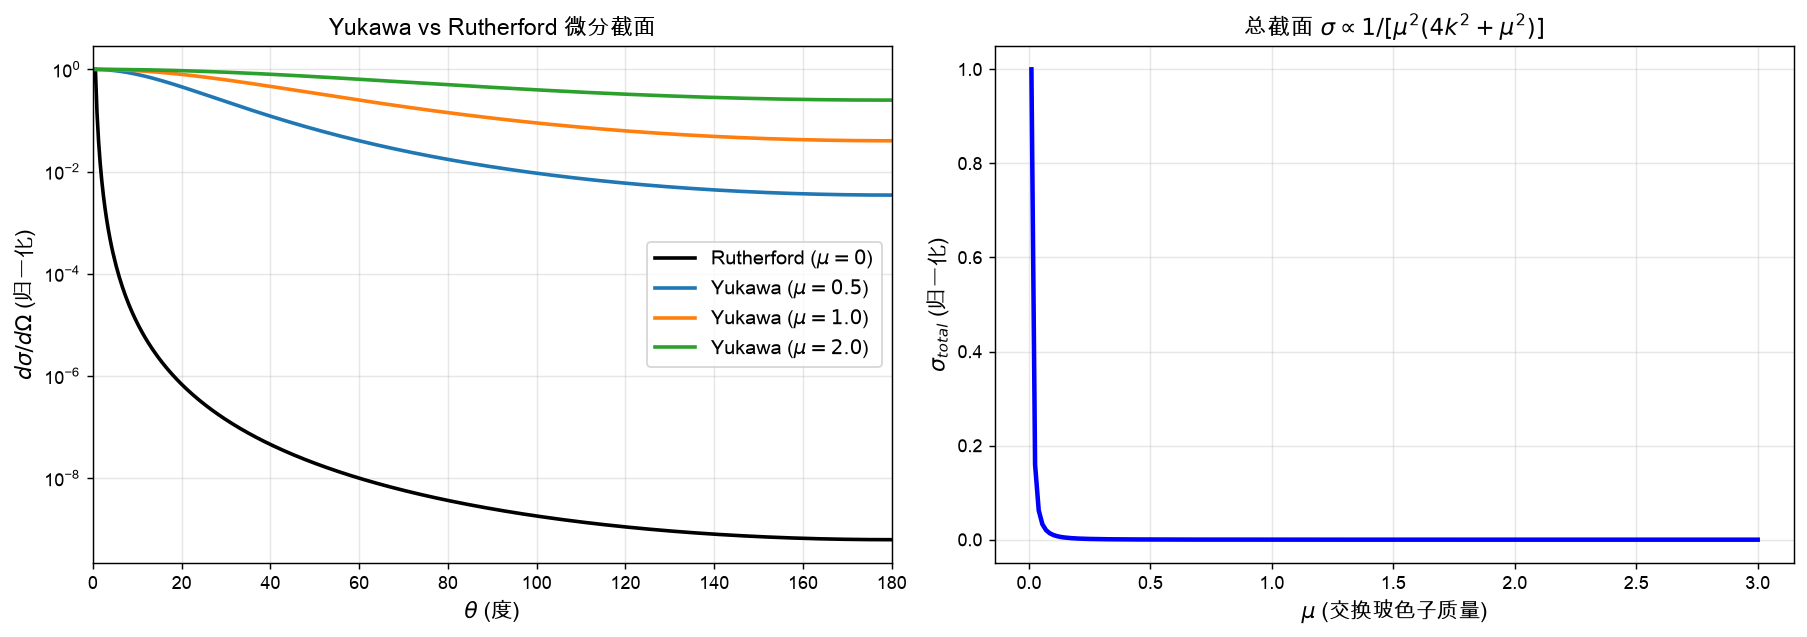

In [10]:
# Yukawa vs Rutherford 散射截面
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
theta_arr = np.linspace(0.01, np.pi, 500)
k_val = 1.0

ax = axes[0]
dsigma_ruth_arr = 1.0 / (4*k_val**2*np.sin(theta_arr/2)**2)**2
ax.semilogy(np.degrees(theta_arr), dsigma_ruth_arr/dsigma_ruth_arr.max(), 'k-', lw=2, label=r'Rutherford ($\mu=0$)')
for mu_val in [0.5, 1.0, 2.0]:
    dsigma_yuk = 1.0 / (4*k_val**2*np.sin(theta_arr/2)**2 + mu_val**2)**2
    ax.semilogy(np.degrees(theta_arr), dsigma_yuk/dsigma_yuk.max(), lw=2, label=rf'Yukawa ($\mu={mu_val}$)')
ax.set_xlabel(r'$\theta$ (度)', fontsize=12)
ax.set_ylabel(r'$d\sigma/d\Omega$ (归一化)', fontsize=12)
ax.set_title('Yukawa vs Rutherford 微分截面', fontsize=13)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3); ax.set_xlim(0, 180)

ax = axes[1]
mu_arr = np.linspace(0.01, 3, 200)
sigma_total = 4*np.pi / (mu_arr**2 * (4*k_val**2 + mu_arr**2))
ax.plot(mu_arr, sigma_total/sigma_total.max(), 'b-', lw=2.5)
ax.set_xlabel(r'$\mu$ (交换玻色子质量)', fontsize=12)
ax.set_ylabel(r'$\sigma_{total}$ (归一化)', fontsize=12)
ax.set_title(r'总截面 $\sigma \propto 1/[\mu^2(4k^2+\mu^2)]$', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig_yukawa_scattering.png', bbox_inches='tight', dpi=150); plt.show()

---
## 7. BEC 的 Fock 空间描述

Bose-Einstein 凝聚：宏观数量粒子占据单粒子基态。

$$|\text{BEC}\rangle \approx \frac{(a_0^\dagger)^N}{\sqrt{N!}}|0\rangle$$

**序参量**（宏观波函数）：$\Psi_0(\mathbf{r}) = \langle\hat{\psi}(\mathbf{r})\rangle = \sqrt{n_0}\,\phi_0(\mathbf{r})$

非零 $\langle\hat{\psi}\rangle$ = $U(1)$ 对称性自发破缺 = 超流。

**Gross-Pitaevskii 方程**：$i\hbar\partial_t\Psi = (-\frac{\hbar^2}{2m}\nabla^2 + V_{ext} + g|\Psi|^2)\Psi$

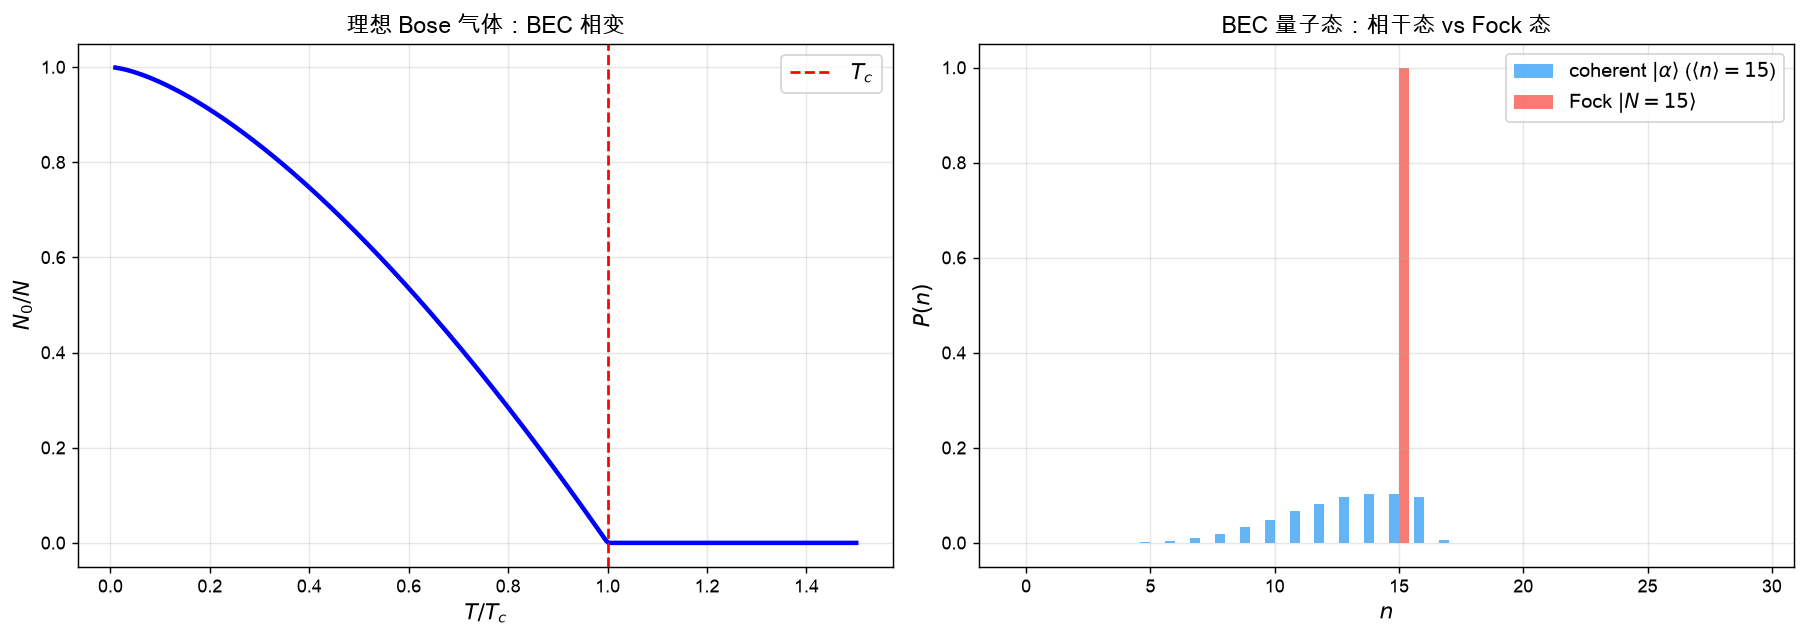

In [11]:
# BEC: 占据数分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
T_ratio = np.linspace(0.01, 1.5, 300)
N0_frac = np.maximum(1 - T_ratio**1.5, 0)
ax.plot(T_ratio, N0_frac, 'b-', lw=2.5)
ax.axvline(1.0, color='r', ls='--', lw=1.5, label=r'$T_c$')
ax.set_xlabel(r'$T/T_c$', fontsize=12)
ax.set_ylabel(r'$N_0/N$', fontsize=12)
ax.set_title('理想 Bose 气体：BEC 相变', fontsize=13)
ax.legend(fontsize=12); ax.grid(True, alpha=0.3)

ax = axes[1]
n_vals = np.arange(0, 30)
alpha_sq = 15
P_coherent = np.exp(-alpha_sq) * alpha_sq**n_vals / np.array([float(sp.factorial(n)) for n in n_vals])
P_fock = np.zeros(30); P_fock[15] = 1.0
ax.bar(n_vals-0.2, P_coherent, width=0.4, alpha=0.7, label=r'coherent $|\alpha\rangle$ ($\langle n\rangle=15$)', color='#2196F3')
ax.bar(n_vals+0.2, P_fock, width=0.4, alpha=0.7, label=r'Fock $|N=15\rangle$', color='#F44336')
ax.set_xlabel(r'$n$', fontsize=12)
ax.set_ylabel('$P(n)$', fontsize=12)
ax.set_title('BEC 量子态：相干态 vs Fock 态', fontsize=13)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig_bec.png', bbox_inches='tight', dpi=150); plt.show()

---
## 8. 总结

```
单粒子 QM → Fock 空间 → 场算符 → Wick 定理 → Green 函数 → 散射截面
```

**关键问题**：
- **二次量子化 ≠ 两次量子化**：把波函数提升为算符，自然处理变粒子数
- **Wick 定理为什么有效**：自由场 = Gaussian → 高阶矩由 2 点函数完全决定
- **Yukawa 截面**：$\sim 1/(q^2+\mu^2)^2$，$\mu$ = 力程倒数 = 交换粒子质量

---
## 练习

1. 用二次量子化语言重写氢原子（$H = \sum_{nlm} E_n a_{nlm}^\dagger a_{nlm}$）
2. 推导 Wick 定理（对 4 个算符，显式写出所有收缩）
3. 手推验证 Yukawa Born 截面
4. 用 Fock 空间描述 BEC 的 $U(1)$ 破缺
5. 计算电子-μ子散射截面（为 M04 QED 做准备）

---
## 9. Dyson 级数 → Feynman 规则

### 相互作用绘景

将 $H = H_0 + H_I$ 拆分。相互作用绘景中：

$$|\psi_I(t)\rangle = e^{iH_0 t/\hbar}|\psi_S(t)\rangle, \qquad H_I(t) = e^{iH_0 t/\hbar} H_I e^{-iH_0 t/\hbar}$$

时间演化算符满足：

$$i\hbar\frac{d}{dt}U(t,t_0) = H_I(t)\,U(t,t_0)$$

### Dyson 级数（迭代解）

$$U(t,t_0) = 1 + \frac{-i}{\hbar}\int_{t_0}^t dt_1\,H_I(t_1) + \frac{(-i)^2}{\hbar^2}\int_{t_0}^t dt_1\int_{t_0}^{t_1} dt_2\,H_I(t_1)H_I(t_2) + \cdots$$

利用编时积消除积分序限制：

$$\boxed{U(t,t_0) = T\exp\!\left(-\frac{i}{\hbar}\int_{t_0}^t H_I(t')\,dt'\right) = \sum_{n=0}^{\infty}\frac{(-i)^n}{n!\,\hbar^n}\int dt_1\cdots dt_n\;T[H_I(t_1)\cdots H_I(t_n)]}$$

### 从 Dyson 到 Feynman 图

对 $T[H_I(t_1)\cdots H_I(t_n)]$ 用 Wick 定理：

1. 每个 $H_I$ 含场算符（如 $\phi^4$ 理论：$H_I = \frac{\lambda}{4!}\phi^4$）
2. Wick 展开 → 所有收缩方案
3. 每个收缩 = 一条传播子线 $G_F(x-y)$
4. 未收缩的场 = 外线
5. 每个完全收缩方案 = 一个 **Feynman 图**

**Feynman 图（tikz-feynman 绘制）：** [fig_dyson_feynman.pdf](fig_dyson_feynman.pdf)

- $n=0$：真空（无图）
- $n=1$：单顶点 tadpole（4 外线）
- $n=2$：树图（2 顶点 + 1 内线）+ 真空泡（2 内线）
- $n=3$：三角形真空图 + 日落图（3 内线）

![Dyson to Feynman](fig_dyson_feynman.png)


---
## 10. 例：$\phi^4$ 理论的 Feynman 规则

$$\mathcal{L} = \frac{1}{2}(\partial\phi)^2 - \frac{1}{2}m^2\phi^2 - \frac{\lambda}{4!}\phi^4$$

相互作用：$H_I = \frac{\lambda}{4!}\int d^3x\;\phi^4(x)$

### 二阶展开（$n=2$）的 Wick 收缩

$$T[\phi^4(x_1)\phi^4(x_2)]$$

8 个场算符的完全收缩 + 部分收缩（外线）。

**Feynman 规则**（动量空间）：

| 元素 | 规则 |
|------|------|
| 内线（传播子） | $\frac{i}{p^2 - m^2 + i\epsilon}$ |
| 顶点 | $-i\lambda$ |
| 动量守恒 | 每个顶点 $(2\pi)^4\delta^{(4)}(\sum p)$ |
| 圈积分 | $\int\frac{d^4k}{(2\pi)^4}$ |
| 对称因子 | 除以图的自同构群阶 $\vert\text{Aut}(G)\vert$ |

In [13]:
# phi^4 二阶: 枚举收缩并识别 Feynman 图
from itertools import combinations

def perfect_matchings(vertices):
    if len(vertices) == 0:
        yield []
        return
    v0 = vertices[0]
    rest = vertices[1:]
    for i, v in enumerate(rest):
        pair = (v0, v)
        remaining = rest[:i] + rest[i+1:]
        for matching in perfect_matchings(remaining):
            yield [pair] + matching

# phi^4(x1) phi^4(x2): 8 个场, 标记为 1a,1b,1c,1d, 2a,2b,2c,2d
# 完全收缩 (真空图): 8 个场全部配对
display(Markdown(r"### $\phi^4$ 二阶真空图（完全收缩）"))
display(Markdown(r"$T[\phi(x_1)^4 \phi(x_2)^4]$: 8 个场算符"))

# 标记: 1,2,3,4 属于 x1; 5,6,7,8 属于 x2
fields = list(range(1, 9))
all_matchings = list(perfect_matchings(fields))
display(Math(r"\text{完全收缩总数} = (8-1)!! = %d" % len(all_matchings)))

# 分类: 几个内线连接 x1-x2
display(Markdown("**按 x1-x2 连线数分类：**"))
categories = {}
for m in all_matchings:
    # 计算跨 x1-x2 的配对数
    cross = sum(1 for a, b in m if (a <= 4) != (b <= 4))
    categories.setdefault(cross, []).append(m)

for n_cross in sorted(categories.keys(), reverse=True):
    count = len(categories[n_cross])
    display(Math(r"x_1\text{-}x_2 \text{ 连线数} = %d: \quad %d \text{ 个收缩}" % (n_cross, count)))

display(Markdown(
    r"**物理意义**：\n"
    r"- 4 条 x1-x2 线 = '8字形'真空泡（对称因子最大）\n"
    r"- 2 条 x1-x2 线 + 各自内部配对 = '日字形'\n"
    r"- 0 条 x1-x2 线 = 两个独立真空泡（断开图，被 $\ln Z$ 排除）"
))

### $\phi^4$ 二阶真空图（完全收缩）

$T[\phi(x_1)^4 \phi(x_2)^4]$: 8 个场算符

<IPython.core.display.Math object>

**按 x1-x2 连线数分类：**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**物理意义**：\n- 4 条 x1-x2 线 = '8字形'真空泡（对称因子最大）\n- 2 条 x1-x2 线 + 各自内部配对 = '日字形'\n- 0 条 x1-x2 线 = 两个独立真空泡（断开图，被 $\ln Z$ 排除）

**$\phi^4$ 二阶真空图拓扑（tikz-feynman 绘制）：** [fig_phi4_vacuum.pdf](fig_phi4_vacuum.pdf)

- 4 条 $x_1$-$x_2$ 内线：8字形（对称因子 $1/48$）
- 2 条内线 + 2 自环：日字形（对称因子 $1/16$）
- 0 条内线：断开图（在 $\ln Z$ 中消失）

![phi4 vacuum](fig_phi4_vacuum.png)


---
## 11. S 矩阵与散射截面

$$S = U(+\infty, -\infty) = T\exp\!\left(-i\int_{-\infty}^{+\infty} H_I(t)\,dt\right)$$

**散射振幅**：$\langle f|S|i\rangle = \delta_{fi} + i(2\pi)^4\delta^{(4)}(p_f - p_i)\mathcal{M}$

**截面**：

$$d\sigma = \frac{|\mathcal{M}|^2}{4E_1 E_2 |v_1 - v_2|} d\Phi_n$$

其中 $d\Phi_n$ 是 $n$ 体末态相空间。

**和 M01 Born 近似的联系**：Born 近似 = S 矩阵的一阶展开（树图）。

findfont: Failed to find font weight bold, now using 400.


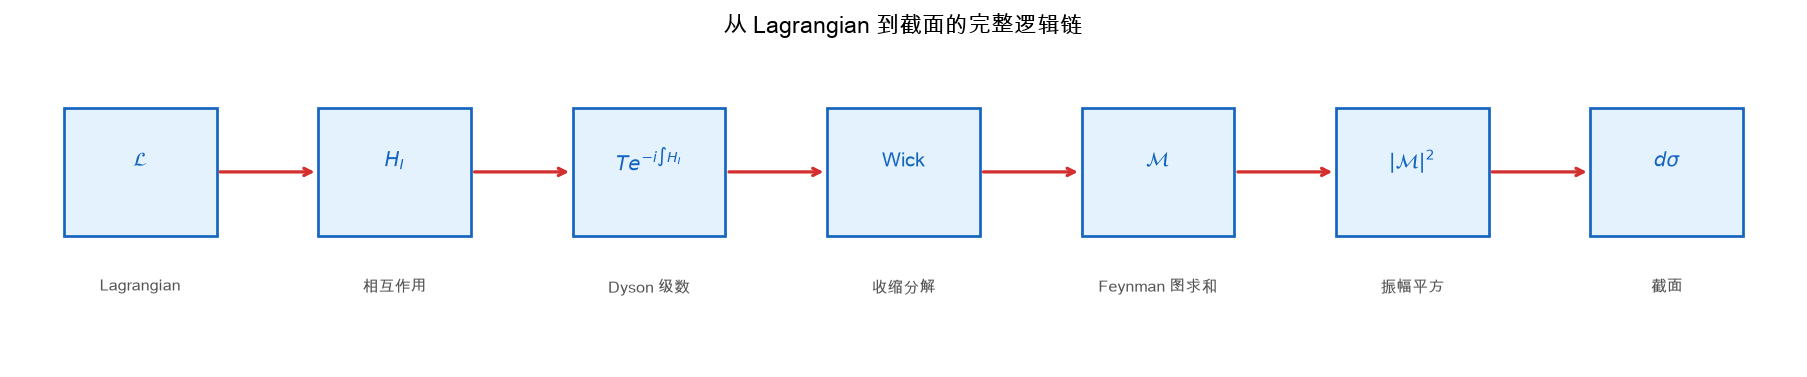

In [15]:
# 总结: 从 Dyson 到截面的完整逻辑链
fig, ax = plt.subplots(figsize=(14, 3))
ax.set_title('从 Lagrangian 到截面的完整逻辑链', fontsize=13, fontweight='bold')

steps = [
    (r'$\mathcal{L}$', 'Lagrangian'),
    (r'$H_I$', '相互作用'),
    (r'$T e^{-i\int H_I}$', 'Dyson 级数'),
    ('Wick', '收缩分解'),
    (r'$\mathcal{M}$', 'Feynman 图求和'),
    (r'$|\mathcal{M}|^2$', '振幅平方'),
    (r'$d\sigma$', '截面'),
]
xpos = np.linspace(0, 12, len(steps))
for i, (sym, desc) in enumerate(steps):
    x = xpos[i]
    rect = plt.Rectangle((x-0.6, -0.3), 1.2, 0.6, facecolor='#E3F2FD', edgecolor='#1565C0', lw=1.5)
    ax.add_patch(rect)
    ax.text(x, 0.05, sym, ha='center', va='center', fontsize=11, color='#1565C0', fontweight='bold')
    ax.text(x, -0.5, desc, ha='center', va='top', fontsize=9, color='#555')
    if i < len(steps)-1:
        ax.annotate('', xy=(xpos[i+1]-0.6, 0), xytext=(x+0.6, 0),
                    arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=1.8))

ax.set_xlim(-1, 13); ax.set_ylim(-0.9, 0.6); ax.axis('off')
plt.tight_layout(); plt.savefig('fig_logic_chain.png', bbox_inches='tight', dpi=150); plt.show()